<blank>

# **RANDOM FOREST**

Valutiamo accuracy e sensitivity di random forest con diversi iperparametri. 

## Preparazione dei dati

---

In [1]:
import numpy as np
# Segnale su cui effettuare Train e Validation
g_0_b = np.loadtxt('data/g_0_signal_b.txt')
g_1_b = np.loadtxt('data/g_1_signal_b.txt')
# Segnale su cui effettuare Test Esterno
g_0_a = np.loadtxt('data/g_0_signal_a.txt')
g_1_a = np.loadtxt('data/g_1_signal_a.txt')

Concatenazione gruppi e vettore dei label:

In [2]:
N0, N1 = g_0_b.shape[0], g_1_b.shape[0]
# concateno g_0 e g_1
signal_b = np.vstack((g_0_b, g_1_b))
signal_a = np.vstack((g_0_a, g_1_a))

# vettore delle risposte
labels = np.concatenate((np.zeros(N0), np.ones(N1))) # uguale per A e B

## Importazioni

---

In [3]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from sklearn.ensemble import RandomForestClassifier as RFC

<blank>

# GridSearch

---

In [4]:
rkf = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

# PCA
N_COMPONENTS_OPTIONS = [5]
# ESTIMATOR
N_ESTIMATOR_OPTIONS = [50, 100, 250]
OBJ_FUNCTION_OPTIONS = ['gini', 'entropy']
MAX_FEATURES_OPTIONS = ["sqrt", "log2"]
MAX_DEPTH_OPTIONS = [2, 3, 5]
MIN_SAMPLES_LEAF_OPTIONS = [1, 2, 5]

# 1. Definizione Pipeline #
pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", StandardScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    #("reduce_dim", PCA(random_state=42)),
    
    # Step 3: Classificatore BOOTSTRAP SEMPRE TRUE PERCHÉ HO POCHI SAMPLES (44)
    ("classify", RFC(random_state=42, bootstrap=True)) 
])

# 2. Definizione griglia dei parametri #
param_grid = {
    
    # Per provare parametri specifici di uno step (PCA)
    #"reduce_dim__n_components": N_COMPONENTS_OPTIONS, 
    
    # Per provare parametri del classificatore
    "classify__n_estimators": N_ESTIMATOR_OPTIONS,
    
    # Per provare diverse objective funcions
    "classify__criterion": OBJ_FUNCTION_OPTIONS,
    
    # Diversi max features
    "classify__max_features": MAX_FEATURES_OPTIONS,
    
    "classify__max_depth": MAX_DEPTH_OPTIONS, # Ferma la crescita dell'albero oltre un certo limite
    
    "classify__min_samples_leaf": MIN_SAMPLES_LEAF_OPTIONS, # Stabilizza le foglie
    
}

# 3. Configurazione GridSearch #
grid = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=rkf,
    n_jobs=-1, # «Number of jobs to run in parallel. -1 means using all processors»
    scoring={
        'score': 'accuracy',
        'sensitivity': 'recall'  # recall = sensitivity
    },
    refit='score', # «For multiple metric evaluation, needs to be a str denoting the
    # scorer to use to find the best parameters for refitting the estimator at the end»
    return_train_score=False
)

# 4. Training e Validation (su Segnale B) #
grid.fit(signal_b, labels)

# 5. Risultati #
print(f"La miglior configurazione: {grid.best_params_}")
print(f"Fornisce accuracy in validation: {grid.best_score_:.4f}")

# 6. Test su segnale A #
accuracy_finale = grid.score(signal_a, labels)
print(f"Risultato sul set indipendente (Segnale A): {accuracy_finale:.4f}")

La miglior configurazione: {'classify__criterion': 'gini', 'classify__max_depth': 3, 'classify__max_features': 'sqrt', 'classify__min_samples_leaf': 1, 'classify__n_estimators': 100}
Fornisce accuracy in validation: 0.7533
Risultato sul set indipendente (Segnale A): 0.4318


In [6]:
import pandas as pd

results_df = pd.DataFrame(grid.cv_results_)
# Ciascuna combinazione di parametri è una riga
print(f"Numero totale di configurazioni provate: {results_df.shape[0]}")

# Selezioniamo solo le colonne interessanti per pulire la vista
columns_to_show = [
    #'param_reduce_dim__n_components', 
    'param_classify__n_estimators', 
    'param_classify__criterion', 
    'param_classify__max_features', 
    'param_classify__max_depth',
    'param_classify__min_samples_leaf',
    'mean_test_score', 
    'std_test_score', 
    'mean_test_sensitivity',
    'rank_test_score'
]

# Ordiniamo per classifica (rank_test_score)
analysis = results_df[columns_to_show].sort_values('rank_test_score')

# Se si ha, è comodo aprire analysis in un viewer tipo Data Wrangler
analysis.head(20)

Numero totale di configurazioni provate: 108


,param_classify__n_estimators,param_classify__criterion,param_classify__max_features,param_classify__max_depth,param_classify__min_samples_leaf,mean_test_score,std_test_score,mean_test_sensitivity,rank_test_score
19,100,gini,sqrt,3,1,0.753333,0.189854,0.785417,1
37,100,gini,sqrt,5,1,0.753333,0.187202,0.779167,1
22,100,gini,sqrt,3,2,0.752083,0.173913,0.779167,3
40,100,gini,sqrt,5,2,0.752083,0.173913,0.779167,3
38,250,gini,sqrt,5,1,0.750417,0.176933,0.789583,5
2,250,gini,sqrt,2,1,0.750000,0.177873,0.791667,6
20,250,gini,sqrt,3,1,0.750000,0.174801,0.793750,6
23,250,gini,sqrt,3,2,0.745000,0.177255,0.779167,8
41,250,gini,sqrt,5,2,0.745000,0.177255,0.779167,8
1,100,gini,sqrt,2,1,0.744167,0.165896,0.781250,10


In [7]:
import pickle as pkl
results_df.to_pickle("results/risultati_GridSearch_rf.pkl")
with open("results/miglior_modello_rf", 'wb') as f:
        pkl.dump(grid.best_estimator_, f)

<blank>

# Analisi degli **iperparametri** più importanti

---

Valutiamo l'accuracy media fissando un iper-parametro per volta, per determinare quali risultano più determinanti. 

In [11]:
# Differenza tra accuracy massima e minima tra le opzioni di un singolo iperparametro
for param in [col for col in results_df.columns if 'param_' in col]:
    stats = results_df.groupby(param)['mean_test_score'].agg(['mean', 'std'])
    delta = stats['mean'].max() - stats['mean'].min()
    print(f"Parametro: {param} | Impatto (Delta): {delta:.4f}")

Parametro: param_classify__criterion | Impatto (Delta): 0.0117
Parametro: param_classify__max_depth | Impatto (Delta): 0.0019
Parametro: param_classify__max_features | Impatto (Delta): 0.0287
Parametro: param_classify__min_samples_leaf | Impatto (Delta): 0.0136
Parametro: param_classify__n_estimators | Impatto (Delta): 0.0075


In [15]:
# Vedere quale valore di n_estimators o min_samples_leaf massimizza la Sensitivity
print(results_df.groupby('param_classify__n_estimators')['mean_test_sensitivity'].mean())

param_classify__n_estimators
50     0.750174
100    0.751620
250    0.749132
Name: mean_test_sensitivity, dtype: float64


----------------------------------------
param_classify__criterion
gini       0.724522
entropy    0.712785
Name: mean_test_score, dtype: float64
----------------------------------------
param_classify__max_depth
3    0.719294
5    0.719294
2    0.717373
Name: mean_test_score, dtype: float64
----------------------------------------
param_classify__max_features
sqrt    0.733025
log2    0.704282
Name: mean_test_score, dtype: float64
----------------------------------------
param_classify__min_samples_leaf
2    0.725220
1    0.719132
5    0.711609
Name: mean_test_score, dtype: float64
----------------------------------------
param_classify__n_estimators
50     0.722002
100    0.719468
250    0.714491
Name: mean_test_score, dtype: float64


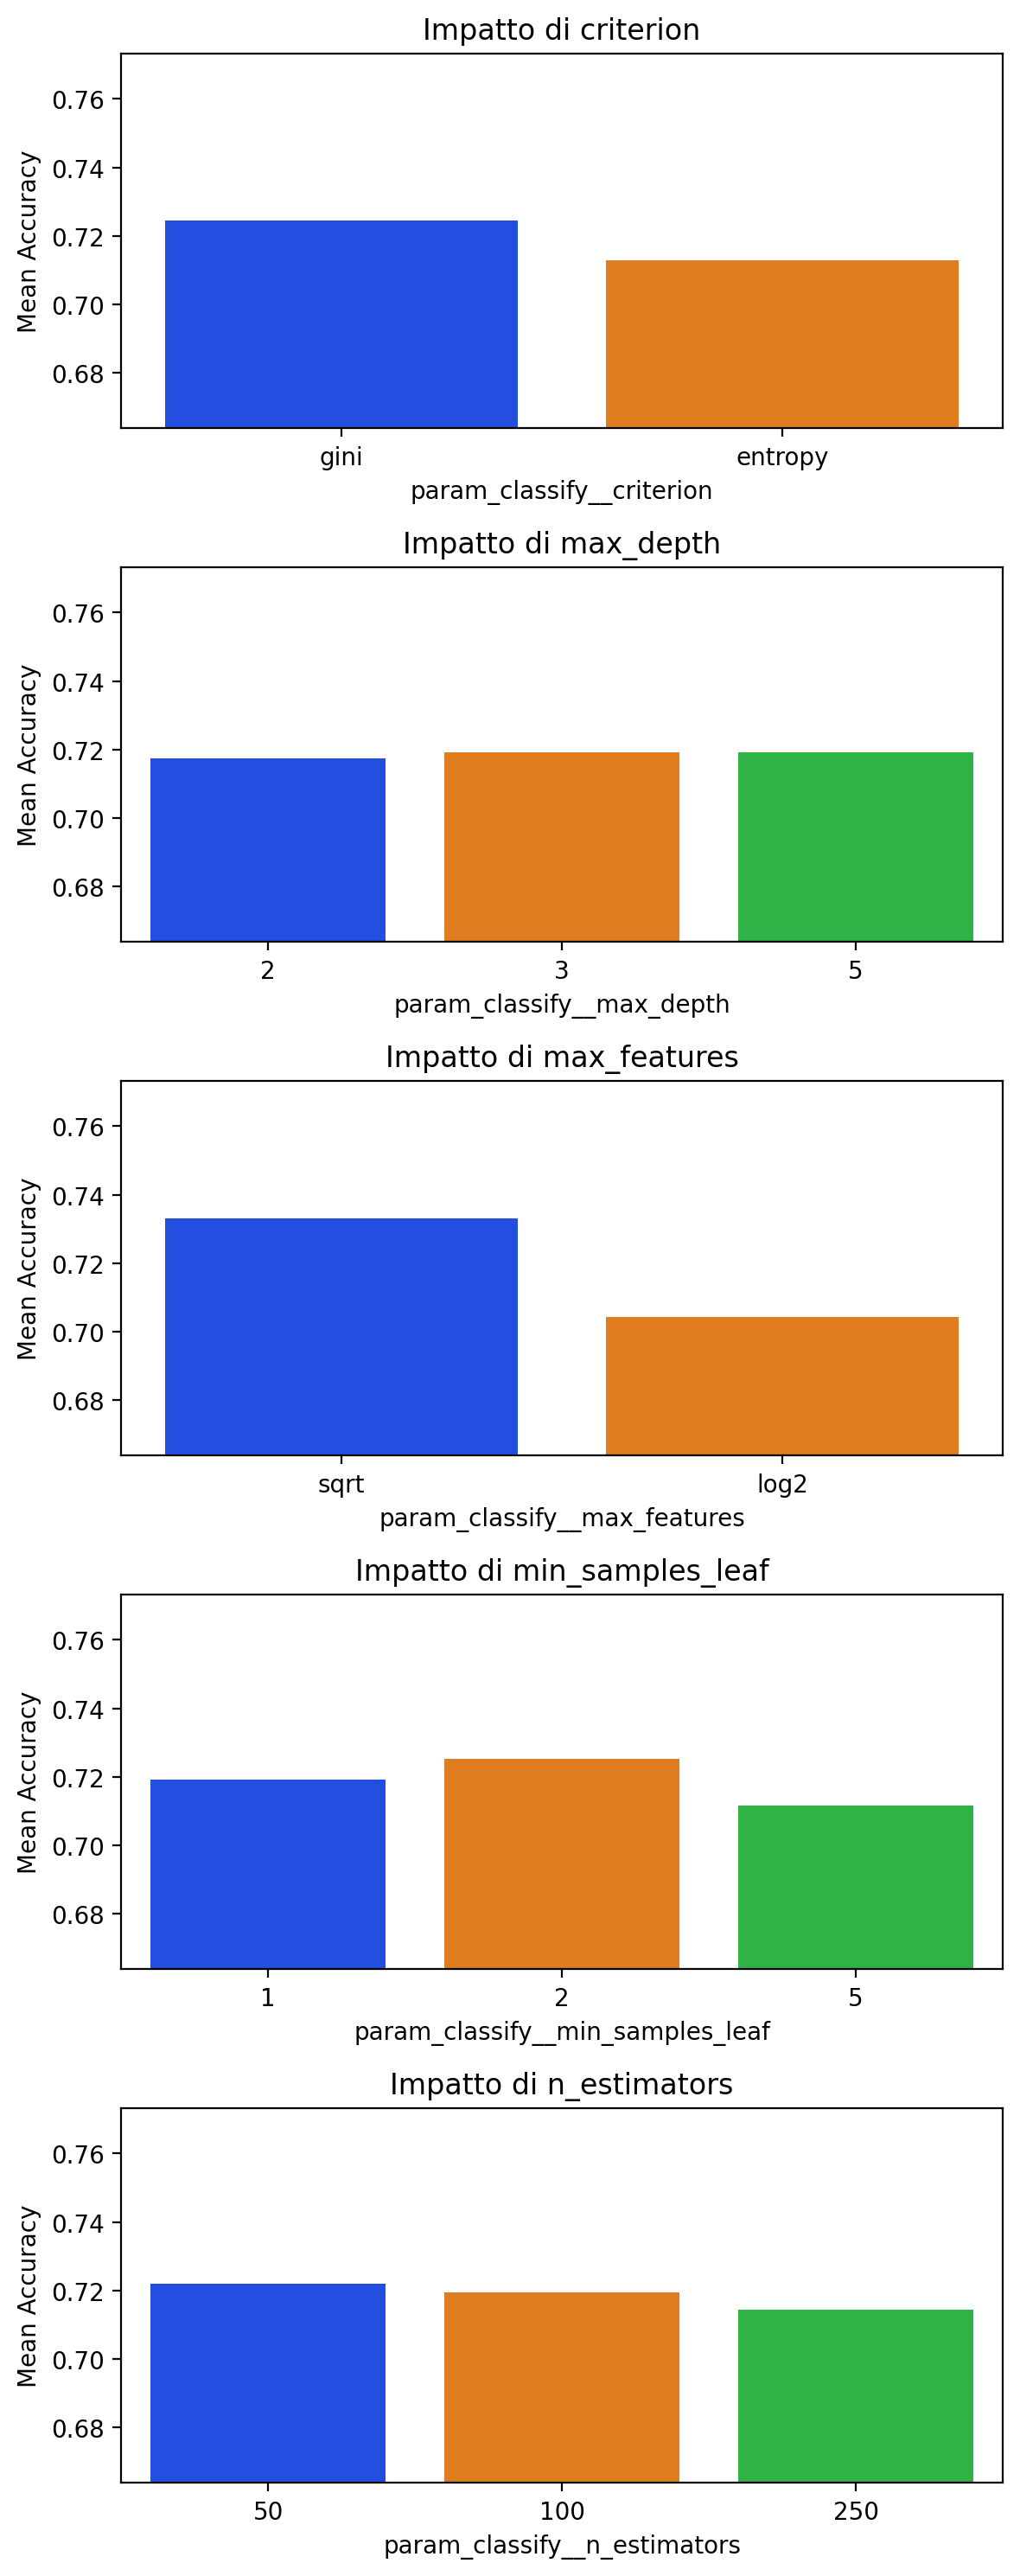

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista dei parametri analizzati
params_to_check = [col for col in results_df.columns if 'param_classify__' in col]

# Figura con vari subplot
fig, axes = plt.subplots(len(params_to_check), 1, figsize=(6, 3 * len(params_to_check)), dpi=150)

for i, param in enumerate(params_to_check):
    # Calcoliamo la media dell'accuracy per ogni valore FISSATO del parametro
    stats = results_df.groupby(param)['mean_test_score'].mean().sort_values(ascending=False)
    
    # Plot
    sns.barplot(x=stats.index, y=stats.values, ax=axes[i], palette="bright", legend=False, hue=stats.index)
    axes[i].set_title(f"Impatto di {param.replace('param_classify__', '')}")
    axes[i].set_ylabel("Mean Accuracy")
    axes[i].set_ylim(results_df['mean_test_score'].min() - 0.02, results_df['mean_test_score'].max() + 0.02)
    
    # Stampa
    print(10*"----")
    print(stats)

plt.tight_layout()
plt.show()

---

## Restringiamo il cerchio

`gini` e `sqrt` vincono di tanto, fissiamoli e variamo il resto. `max_depth`praticamente non cambia niente tra 3 e 5, fissiamo a 4. `min_samples_leaf`è sempre migliore tra 1 e 2.

In [18]:
rkf = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

# PCA
N_COMPONENTS_OPTIONS = [5]
# ESTIMATOR
N_ESTIMATOR_OPTIONS = [50, 75, 100, 125, 150, 175, 200]
MIN_SAMPLES_LEAF_OPTIONS = [1, 2]

# 1. Definizione Pipeline #
pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", StandardScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    #("reduce_dim", PCA(random_state=42)),
    
    # Step 3: Classificatore BOOTSTRAP SEMPRE TRUE PERCHÉ HO POCHI SAMPLES (44)
    ("classify", RFC(
        random_state=42, 
        bootstrap=True, 
        criterion='gini',
        max_features = 'sqrt',
        max_depth=4,
        )
    ) 
])

# 2. Definizione griglia dei parametri #
param_grid = {
    
    # Per provare parametri specifici di uno step (PCA)
    #"reduce_dim__n_components": N_COMPONENTS_OPTIONS, 
    
    # Per provare parametri del classificatore
    "classify__n_estimators": N_ESTIMATOR_OPTIONS,
    "classify__min_samples_leaf": MIN_SAMPLES_LEAF_OPTIONS, # Stabilizza le foglie
    
}

# 3. Configurazione GridSearch #
grid = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=rkf,
    n_jobs=-1, # «Number of jobs to run in parallel. -1 means using all processors»
    scoring={
        'score': 'accuracy',
        'sensitivity': 'recall'  # recall = sensitivity
    },
    refit='score', # «For multiple metric evaluation, needs to be a str denoting the
    # scorer to use to find the best parameters for refitting the estimator at the end»
    return_train_score=False
)

# 4. Training e Validation (su Segnale B) #
grid.fit(signal_b, labels)

# 5. Risultati #
print(f"La miglior configurazione: {grid.best_params_}")
print(f"Fornisce accuracy in validation: {grid.best_score_:.4f}")

# 6. Test su segnale A #
accuracy_finale = grid.score(signal_a, labels)
print(f"Risultato sul set indipendente (Segnale A): {accuracy_finale:.4f}")

La miglior configurazione: {'classify__min_samples_leaf': 1, 'classify__n_estimators': 100}
Fornisce accuracy in validation: 0.7533
Risultato sul set indipendente (Segnale A): 0.4318


In [19]:
results_df_2 = pd.DataFrame(grid.cv_results_)
# Ciascuna combinazione di parametri è una riga
print(f"Numero totale di configurazioni provate: {results_df_2.shape[0]}")

# Selezioniamo solo le colonne interessanti per pulire la vista
columns_to_show = [
    #'param_reduce_dim__n_components', 
    'param_classify__n_estimators', 
    'param_classify__min_samples_leaf',
    'mean_test_score', 
    'std_test_score', 
    'mean_test_sensitivity',
    'rank_test_score'
]

# Ordiniamo per classifica (rank_test_score)
analysis_2 = results_df_2[columns_to_show].sort_values('rank_test_score')

# Se si ha, è comodo aprire analysis in un viewer tipo Data Wrangler
analysis_2.head(20)

Numero totale di configurazioni provate: 14


,param_classify__n_estimators,param_classify__min_samples_leaf,mean_test_score,std_test_score,mean_test_sensitivity,rank_test_score
2,100,1,0.753333,0.187202,0.779167,1
9,100,2,0.752083,0.173913,0.779167,2
1,75,1,0.749167,0.174242,0.764583,3
5,175,1,0.748750,0.174956,0.781250,4
6,200,1,0.748750,0.172960,0.772917,4
4,150,1,0.740417,0.172940,0.762500,6
13,200,2,0.739583,0.179976,0.766667,7
3,125,1,0.739583,0.176076,0.772917,8
12,175,2,0.735833,0.173347,0.768750,9
0,50,1,0.733333,0.176698,0.741667,10


----------------------------------------
param_classify__min_samples_leaf
1    0.744762
2    0.734881
Name: mean_test_score, dtype: float64
----------------------------------------
param_classify__n_estimators
100    0.752708
200    0.744167
175    0.742292
75     0.740417
150    0.735208
50     0.732083
125    0.731875
Name: mean_test_score, dtype: float64


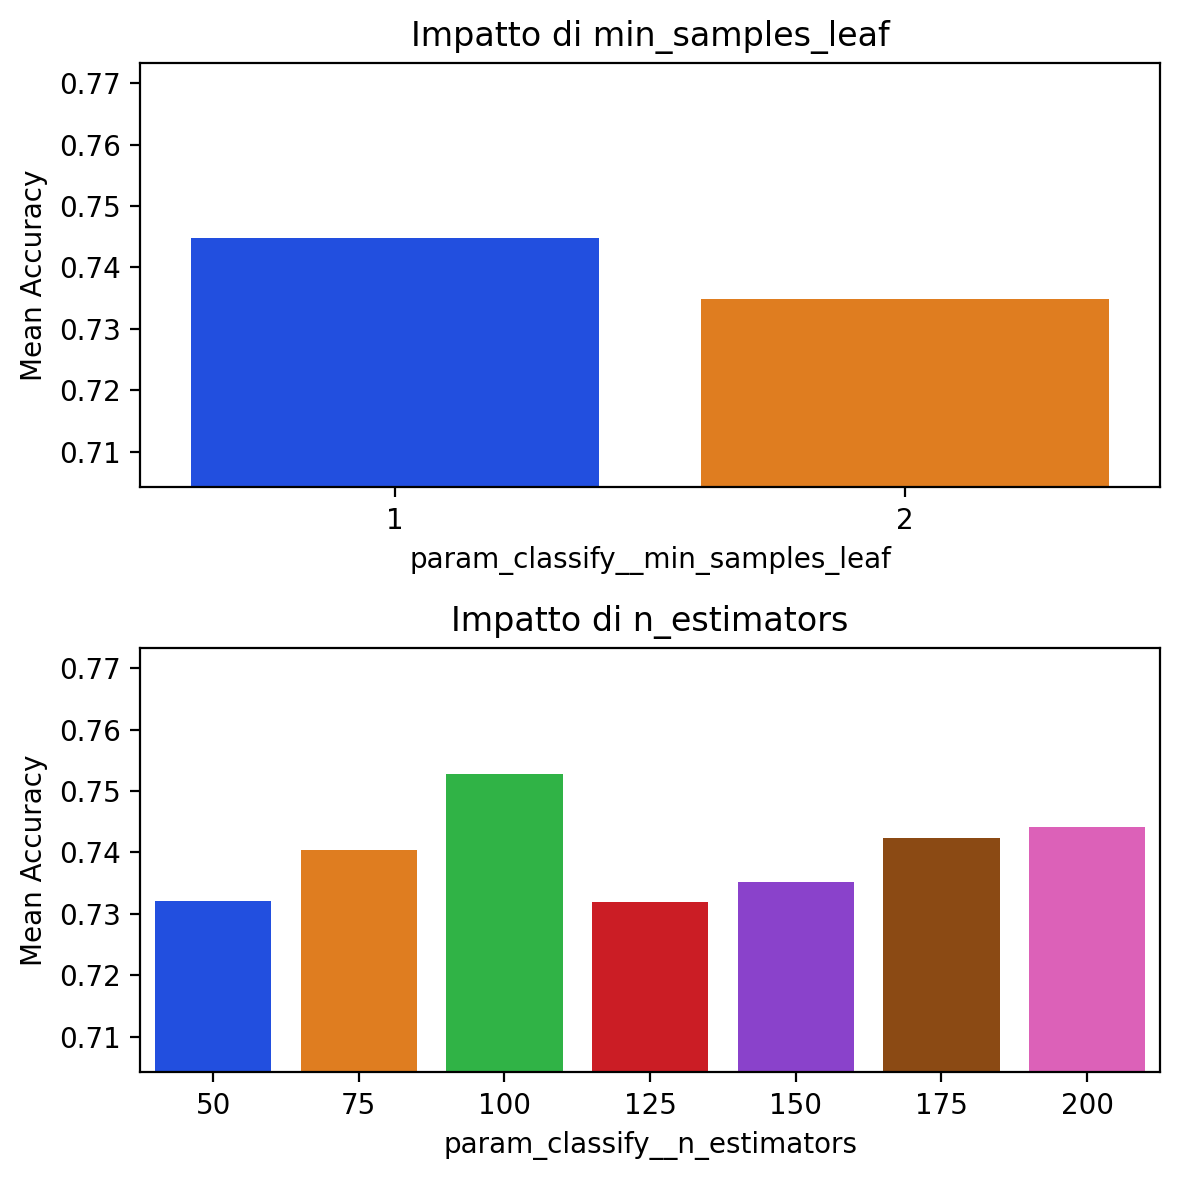

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista dei parametri che abbiamo analizzato
params_to_check = [col for col in results_df_2.columns if 'param_classify__' in col]

# Creiamo una figura con vari subplot
fig, axes = plt.subplots(len(params_to_check), 1, figsize=(6, 3 * len(params_to_check)), dpi=200)

for i, param in enumerate(params_to_check):
    # Calcoliamo la media dell'accuracy per ogni valore del parametro
    stats = results_df_2.groupby(param)['mean_test_score'].mean().sort_values(ascending=False)
    
    # Plotting
    sns.barplot(x=stats.index, y=stats.values, ax=axes[i], palette="bright", legend=False, hue=stats.index)
    axes[i].set_title(f"Impatto di {param.replace('param_classify__', '')}")
    axes[i].set_ylabel("Mean Accuracy")
    axes[i].set_ylim(results_df_2['mean_test_score'].min() - 0.02, results_df_2['mean_test_score'].max() + 0.02)
    
    # Stampiamo i valori testuali per precisione
    print(10*"----")
    print(stats)

plt.tight_layout()
plt.show()

## Preparazione dei dati

---

In [ ]:
import numpy as np
# Segnale su cui effettuare Train e Validation
g_0_b = np.loadtxt('data/g_0_signal_b.txt')
g_1_b = np.loadtxt('data/g_1_signal_b.txt')
# Segnale su cui effettuare Test Esterno
g_0_a = np.loadtxt('data/g_0_signal_a.txt')
g_1_a = np.loadtxt('data/g_1_signal_a.txt')

Concatenazione gruppi e vettore dei label:

In [ ]:
N0, N1 = g_0_b.shape[0], g_1_b.shape[0]
# concateno g_0 e g_1
signal_b = np.vstack((g_0_b, g_1_b))
signal_a = np.vstack((g_0_a, g_1_a))

# vettore delle risposte
labels = np.concatenate((np.zeros(N0), np.ones(N1))) # uguale per A e B

<blank>

## Variando il numero di fold

---

Stavolta niente `GridSearch`, facciamo due cicli `for` manuali su `k` e `n_estimators`.

In [ ]:
# dizionari per i risultati
acc_dict, std_dict = {}, {}

In [ ]:
from sklearn.model_selection import cross_val_score

k_list = np.arange(2, 23, 1)
N_ESTIMATOR_OPTIONS = [50, 75, 100, 125, 150, 175, 200]

for k in k_list:
    acc_dict[k] = []
    std_dict[k] = []
    n_repeats = 20 if k < 15 else 10 
    rkf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)
    print(f"- k={k}")
    
    for N_e in N_ESTIMATOR_OPTIONS:

        pipe = Pipeline([
            ("scaling", StandardScaler()),       
            #("reduce_dim", PCA(n_components=5, random_state=42)),
            ("classify", RFC(
                n_estimators=N_e, 
                bootstrap=True, 
                criterion='gini',
                max_features = 'sqrt',
                min_samples_leaf = 1,
                max_depth=4,
                random_state=42)) 
        ])
        
        acc = cross_val_score(
            pipe, 
            X=signal_b, 
            y=labels, 
            cv=rkf,
            n_jobs=-1
        )
        
        m, s = acc.mean(), acc.std()
        
        print(f"   • N_e = {N_e}, acc = {m:.3f} ± {s:.3f}", flush=True)
        
        acc_dict[k].append(m)
        std_dict[k].append(s)

- k=2


   • N_e = 50, acc = 0.649 ± 0.080
   • N_e = 75, acc = 0.668 ± 0.080
   • N_e = 100, acc = 0.672 ± 0.064
   • N_e = 125, acc = 0.667 ± 0.069
   • N_e = 150, acc = 0.681 ± 0.081
   • N_e = 175, acc = 0.678 ± 0.072
   • N_e = 200, acc = 0.678 ± 0.076
- k=3
   • N_e = 50, acc = 0.688 ± 0.122
   • N_e = 75, acc = 0.704 ± 0.111
   • N_e = 100, acc = 0.692 ± 0.103
   • N_e = 125, acc = 0.701 ± 0.110
   • N_e = 150, acc = 0.709 ± 0.120
   • N_e = 175, acc = 0.709 ± 0.116
   • N_e = 200, acc = 0.710 ± 0.115
- k=4
   • N_e = 50, acc = 0.709 ± 0.130
   • N_e = 75, acc = 0.715 ± 0.128
   • N_e = 100, acc = 0.716 ± 0.126
   • N_e = 125, acc = 0.713 ± 0.126
   • N_e = 150, acc = 0.730 ± 0.133
   • N_e = 175, acc = 0.731 ± 0.129
   • N_e = 200, acc = 0.731 ± 0.126
- k=5
   • N_e = 50, acc = 0.703 ± 0.153
   • N_e = 75, acc = 0.715 ± 0.151
   • N_e = 100, acc = 0.711 ± 0.152
   • N_e = 125, acc = 0.703 ± 0.151
   • N_e = 150, acc = 0.716 ± 0.142
   • N_e = 175, acc = 0.715 ± 0.151
   • N_e = 200, ac

In [ ]:
# Creiamo il DataFrame: le chiavi del dizionario (k) diventano le colonne
# L'indice (le righe) sarà la lista degli stimatori che hai usato
df_acc = pd.DataFrame(acc_dict, index=N_ESTIMATOR_OPTIONS)

# Rinominiamo gli assi per chiarezza
df_acc.index.name = "N Estimators"
df_acc.columns.name = "k Folds"

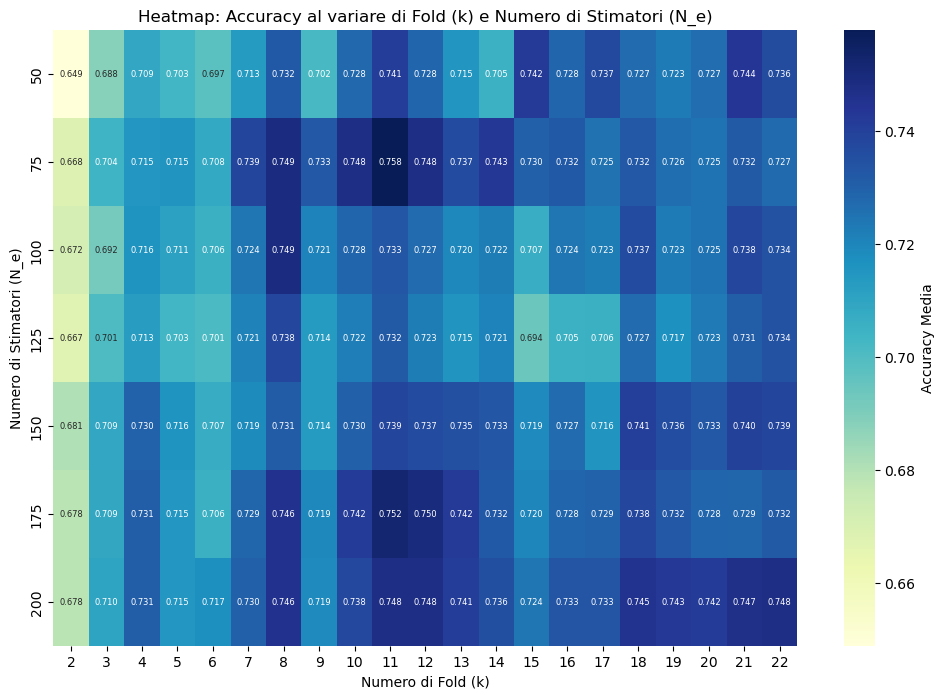

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_acc, 
    annot=True,      # Scrive il valore dell'accuracy dentro ogni cella
    fmt=".3f",       # Formato a 3 decimali
    cmap="YlGnBu",   # Colormap dal giallo (basso) al blu (alto)
    cbar_kws={'label': 'Accuracy Media'},
    annot_kws={"size": 6}
)

plt.title("Heatmap: Accuracy al variare di Fold (k) e Numero di Stimatori (N_e)")
plt.xlabel("Numero di Fold (k)")
plt.ylabel("Numero di Stimatori (N_e)")
plt.show()